# Drug Safety Analysis: Adverse Effect Detection in a Randomized Controlled Trial

---

**Author:** [Your Name]  
**Date:** 2024  
**Dataset:** Drug Safety RCT — Vanderbilt University Department of Biostatistics (via Hbiostat)  
**Status:** Complete  

---

## 1. Business Understanding

GlobalXYZ, a pharmaceutical company, has completed a randomized controlled trial (RCT) for a new drug and has shared the trial dataset with our organization — a non-profit focused on drug safety oversight.

Our primary mandate is to independently evaluate whether the drug is associated with adverse reactions at a statistically and clinically meaningful rate.

### Problem Statement

**Are adverse reactions associated with the drug treatment at a statistically and clinically significant level, controlling for demographic and physiological covariates?**

### Objectives

1. **EDA:** Understand the distribution of adverse effects, demographics, and vital signs.
2. **Missingness Analysis:** Determine the mechanism of missing data and apply appropriate imputation.
3. **Statistical Testing:** Formally test whether sex, age, WBC count, or RBC count are associated with adverse effects.
4. **Treatment Effect:** Test whether drug vs. placebo is associated with adverse effects.
5. **Predictive Modelling:** Build a logistic regression classifier to predict adverse effect occurrence.
6. **Conclusions:** Deliver a plain-language safety summary answering the business question.

## 2. Dataset Description

The dataset was obtained from [Hbiostat](https://hbiostat.org/data/) courtesy of Vanderbilt University's Department of Biostatistics and modified for this project.

| Column | Type | Description |
|---|---|---|
| `sex` | Categorical | Biological sex of the participant (`male` / `female`) |
| `age` | Continuous | Age of the participant in years |
| `week` | Ordinal | Week of drug testing |
| `trx` | Categorical | Treatment group: `Drug` or `Placebo` |
| `wbc` | Continuous | White blood cell count (×10³/μL) |
| `rbc` | Continuous | Red blood cell count (×10⁶/μL) |
| `adverse_effects` | Binary | Whether at least one adverse effect occurred (`Yes` / `No`) |
| `num_effects` | Count | Number of adverse effects experienced |

**Study design:** Drug-to-placebo ratio is 2:1 (twice as many drug participants as placebo).

## 3. Import Libraries & Configuration

All imports are consolidated here. A fixed random seed is set globally to ensure full reproducibility.

In [ ]:
# ── Standard Library ──────────────────────────────────────────────────────────
import warnings
warnings.filterwarnings('ignore')

# ── Data Handling ─────────────────────────────────────────────────────────────
import numpy as np
import pandas as pd

# ── Visualisation ─────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# ── Statistics ────────────────────────────────────────────────────────────────
from scipy import stats
from scipy.stats import chi2_contingency, mannwhitneyu, shapiro
import pingouin as pg
from statsmodels.stats.multitest import multipletests
from statsmodels.stats.proportion import proportions_ztest

# ── Machine Learning ──────────────────────────────────────────────────────────
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_validate, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    roc_auc_score, roc_curve, RocCurveDisplay,
    ConfusionMatrixDisplay
)

# ── Missingness ───────────────────────────────────────────────────────────────
try:
    from pyampute.exploration.mcar_statistical_tests import MCARTest
    MCAR_AVAILABLE = True
except ImportError:
    MCAR_AVAILABLE = False

# ── Configuration ─────────────────────────────────────────────────────────────
RANDOM_STATE   = 42
TEST_SIZE      = 0.20
ALPHA          = 0.05        # Family-wise significance threshold (pre-Bonferroni)
N_CV_FOLDS     = 5
FIGURE_SIZE    = (10, 5)
PALETTE        = 'Set2'

np.random.seed(RANDOM_STATE)

# ── Plot Defaults ─────────────────────────────────────────────────────────────
sns.set_theme(style='whitegrid', palette=PALETTE, font_scale=1.1)
plt.rcParams.update({'figure.dpi': 120, 'figure.figsize': FIGURE_SIZE})

print("Environment ready. Random seed:", RANDOM_STATE)

Environment ready. Random seed: 42


## 4. Data Loading

In [85]:
DATA_PATH = "D:\\Summer 2026\\Hypothesis Testing in Healthcare\\drug_safety.csv"

df = pd.read_csv(DATA_PATH)

# Enforce consistent string casing to avoid silent mismatches later
str_cols = df.select_dtypes('object').columns
df[str_cols] = df[str_cols].apply(lambda s: s.str.strip().str.capitalize())

print(f"Dataset loaded: {df.shape[0]:,} rows × {df.shape[1]} columns")

Dataset loaded: 16,103 rows × 8 columns


## 5. Data Overview

In [86]:
print("── Shape ────────────────────────────────────")
print(f"{df.shape[0]:,} rows, {df.shape[1]} columns\n")

print("── dtypes ───────────────────────────────────")
print(df.dtypes, "\n")

print("── First 5 rows ─────────────────────────────")
df.head()

── Shape ────────────────────────────────────
16,103 rows, 8 columns

── dtypes ───────────────────────────────────
age                  int64
sex                 object
trx                 object
week                 int64
wbc                float64
rbc                float64
adverse_effects     object
num_effects          int64
dtype: object 

── First 5 rows ─────────────────────────────


,age,sex,trx,week,wbc,rbc,adverse_effects,num_effects
0,62,Male,Drug,0,7.3,5.1,No,0
1,62,Male,Drug,1,NaN,NaN,No,0
2,62,Male,Drug,12,5.6,5.0,No,0
3,62,Male,Drug,16,NaN,NaN,No,0
4,62,Male,Drug,2,6.6,5.1,No,0


In [87]:
print("── Numerical Summary ────────────────────────")
df.describe(percentiles=[.25, .5, .75]).T

── Numerical Summary ────────────────────────


,count,mean,std,min,25%,50%,75%,max
age,16103.0,64.117556,8.783207,39.0,58.0,65.0,71.0,84.0
week,16103.0,7.740980,6.943500,0.0,1.0,4.0,12.0,20.0
wbc,9128.0,7.340557,1.996652,1.8,6.0,7.1,8.4,26.5
rbc,9127.0,4.672784,0.458520,2.1,4.4,4.7,5.0,7.6
num_effects,16103.0,0.101596,0.323181,0.0,0.0,0.0,0.0,3.0


In [88]:
print("── Categorical Value Counts ─────────────────")
cat_cols = ['sex', 'trx', 'adverse_effects']
for col in cat_cols:
    counts = df[col].value_counts()
    pcts   = df[col].value_counts(normalize=True).mul(100).round(1)
    summary = pd.DataFrame({'n': counts, '%': pcts})
    print(f"\n{col}:\n{summary}")

── Categorical Value Counts ─────────────────

sex:
            n     %
sex                
Male    12328  76.6
Female   3775  23.4

trx:
             n     %
trx                 
Drug     10727  66.6
Placebo   5376  33.4

adverse_effects:
                     n     %
adverse_effects             
No               14567  90.5
Yes               1536   9.5


## 6. Data Quality Assessment

### 6.1 Duplicate Rows

In [89]:
n_dups = df.duplicated().sum()
print(f"Duplicate rows: {n_dups}")
if n_dups > 0:
    df = df.drop_duplicates()
    print(f"Duplicates removed. New shape: {df.shape}")
else:
    print("No duplicates found — dataset is clean on this dimension.")

Duplicate rows: 5791
Duplicates removed. New shape: (10312, 8)


### 6.2 Missing Values

In [90]:
missing = (
    df.isnull().sum()
    .to_frame('n_missing')
    .assign(pct_missing=lambda x: (x['n_missing'] / len(df) * 100).round(2))
    .query('n_missing > 0')
    .sort_values('pct_missing', ascending=False)
)

print("Columns with missing values:")
print(missing if not missing.empty else "None")

Columns with missing values:
     n_missing  pct_missing
rbc       1263        12.25
wbc       1262        12.24


### 6.3 Missing Data Mechanism (Little's MCAR Test)

Before choosing an imputation strategy, we must determine **why** data is missing:

- **MCAR** (Missing Completely At Random): Missing values are independent of observed and unobserved data. Simple imputation is defensible.
- **MAR** (Missing At Random): Missingness depends on observed data. Conditional imputation or multiple imputation is appropriate.
- **MNAR** (Missing Not At Random): Missingness depends on the unobserved value itself. Requires specialised models.

**Little's test** (H₀: data is MCAR) gives a statistical basis for this decision.

In [91]:
if not missing.empty:
    if MCAR_AVAILABLE:
        mcar_test = MCARTest(method='little')
        p_mcar = mcar_test.little_mcar_test(df.select_dtypes(include='number'))
        print(f"Little's MCAR Test p-value: {p_mcar:.4f}")
        if p_mcar < ALPHA:
            print("→ Reject H₀: Data is NOT MCAR (likely MAR or MNAR).")
            print("  Interpretation: Missingness is systematic, not random.")
            print("  Strategy: Conditional median imputation grouped by sex (a proxy for MAR).")
            print("  Note: For production, consider IterativeImputer (MICE) for more rigour.")
        else:
            print("→ Fail to reject H₀: Data is likely MCAR.")
            print("  Strategy: Simple median imputation is defensible.")
    else:
        print("pyampute not available — skipping Little's test.")
        print("Proceeding with exploratory missingness analysis.")

Little's MCAR Test p-value: 0.0000
→ Reject H₀: Data is NOT MCAR (likely MAR or MNAR).
  Interpretation: Missingness is systematic, not random.
  Strategy: Conditional median imputation grouped by sex (a proxy for MAR).
  Note: For production, consider IterativeImputer (MICE) for more rigour.


In [92]:
# Investigate whether missingness is concentrated in a particular sex group
if not missing.empty:
    missing_cols = missing.index.tolist()
    print("Missingness by sex group:")
    for col in missing_cols:
        print(f"\n  {col}:")
        print(df.groupby('sex')[col].apply(lambda x: x.isnull().sum()).rename('n_missing'))

Missingness by sex group:

  rbc:
sex
Female    525
Male      738
Name: n_missing, dtype: int64

  wbc:
sex
Female    524
Male      738
Name: n_missing, dtype: int64


### 6.4 Imputation

**⚠️ Critical: Imputation must be fitted on training data only.**  
To prevent data leakage, we defer column-level imputation to the ML Pipeline (Section 10). For statistical analysis (Sections 7–9), we apply exploratory imputation on the full dataset (No data leakage concern) — clearly labelled as such, and not used for any predictive claims.

> **Teaching note:** Common mistake is to impute the entire dataset before the train/test split. This leaks test-set statistics (medians) into training, inflating apparent model performance. The correct pattern is: Split → Fit imputer on train → Transform both sets.

In [93]:
def impute_by_group_median(dataframe: pd.DataFrame, cols: list, group_col: str) -> pd.DataFrame:
# Docstring added for clarity and maintainability
    """ 
    Impute missing values in `cols` using the median within each `group_col` group.
    Returns a copy; does not modify the original dataframe.
    """
    df_out = dataframe.copy()
    for col in cols:
        df_out[col] = df_out.groupby(group_col)[col].transform(
            lambda x: x.fillna(x.median())
        )
    return df_out


if not missing.empty:
    missing_num_cols = missing.index.tolist()
    df = impute_by_group_median(df, missing_num_cols, group_col='sex')
    print(f"Imputed {missing_num_cols} using sex-group median.")
    print(f"Remaining missing values: {df.isnull().sum().sum()}")

Imputed ['rbc', 'wbc'] using sex-group median.
Remaining missing values: 0



**Why impute by sex group?**

> This is a domain-driven imputation as WBC and RBC have well-established biological reference ranges that differ
> by sex. Using the sex-group median preserves these natural differences
> rather than blending two distinct distributions into a single population
> median. Imputing by `trx` (Drug vs. Placebo) was deliberately avoided —
> if the drug affects blood counts, imputing by treatment group would
> suppress the very signal we are testing for.


## 7. Exploratory Data Analysis

Good EDA tells a story. We structure visualisations to answer progressively deeper questions:
1. What does the target variable look like?
2. How do demographics relate to adverse effects?
3. Does the treatment group show a different adverse effect rate?
4. How do blood counts behave across groups?

### 7.1 Target Variable Distribution

The most fundamental EDA question for a classification problem: **how balanced is the target?**

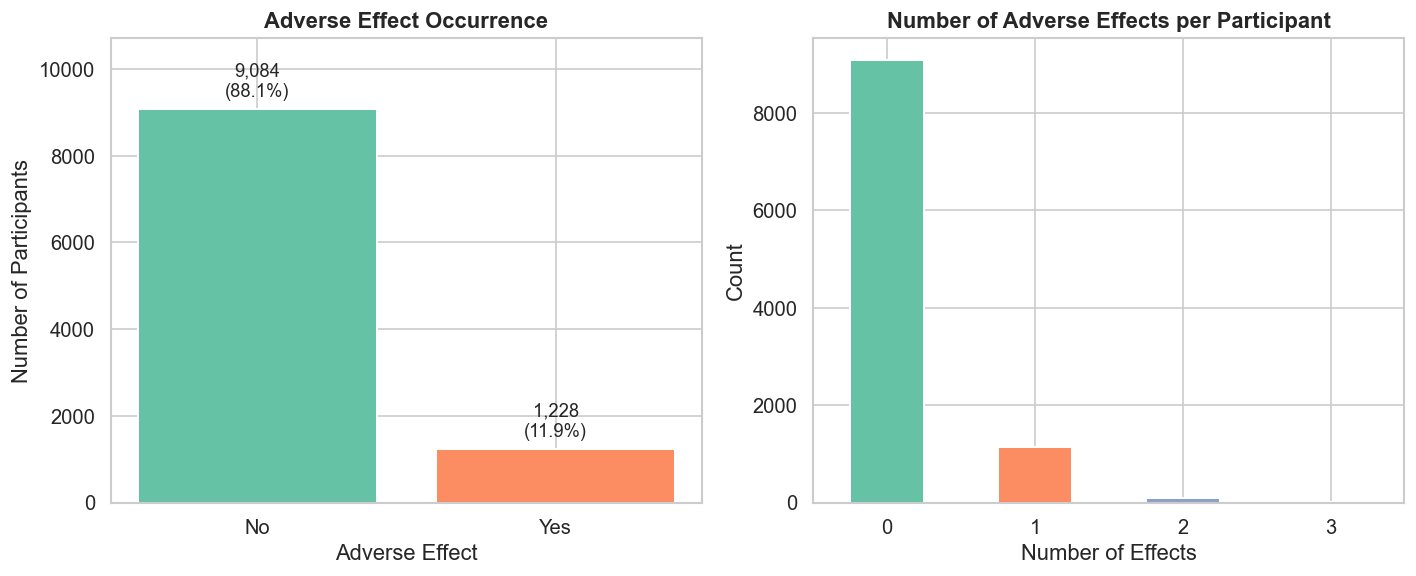

In [94]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Left: Count plot
target_counts = df['adverse_effects'].value_counts()
ax = axes[0]
bars = ax.bar(target_counts.index, target_counts.values,
              color=sns.color_palette(PALETTE, 2), edgecolor='white', linewidth=1.2)
ax.bar_label(bars, labels=[f'{v:,}\n({v/len(df)*100:.1f}%)' for v in target_counts.values],
             padding=5, fontsize=11)
ax.set_title('Adverse Effect Occurrence', fontweight='bold')
ax.set_xlabel('Adverse Effect')
ax.set_ylabel('Number of Participants')
ax.set_ylim(0, target_counts.max() * 1.18)

# Right: Number of effects distribution
ax2 = axes[1]
df['num_effects'].value_counts().sort_index().plot(
    kind='bar', ax=ax2, color=sns.color_palette(PALETTE, df['num_effects'].nunique()),
    edgecolor='white', linewidth=1.2
)
ax2.set_title('Number of Adverse Effects per Participant', fontweight='bold')
ax2.set_xlabel('Number of Effects')
ax2.set_ylabel('Count')
ax2.tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.savefig('fig1_target_distribution.png', bbox_inches='tight')
plt.show()

**Observation:** The target variable is imbalanced — most participants did not experience adverse effects. This is expected in a safety trial and is an important signal for modelling: a naive model predicting 'No' every time would achieve deceptively high accuracy. We must use stratified splits, appropriate metrics (F1, AUC-ROC), and consider class weighting.

### 7.2 Adverse Effects by Treatment Group

This is the central RCT question. If the drug causes adverse effects, we expect a meaningfully higher proportion in the Drug group.

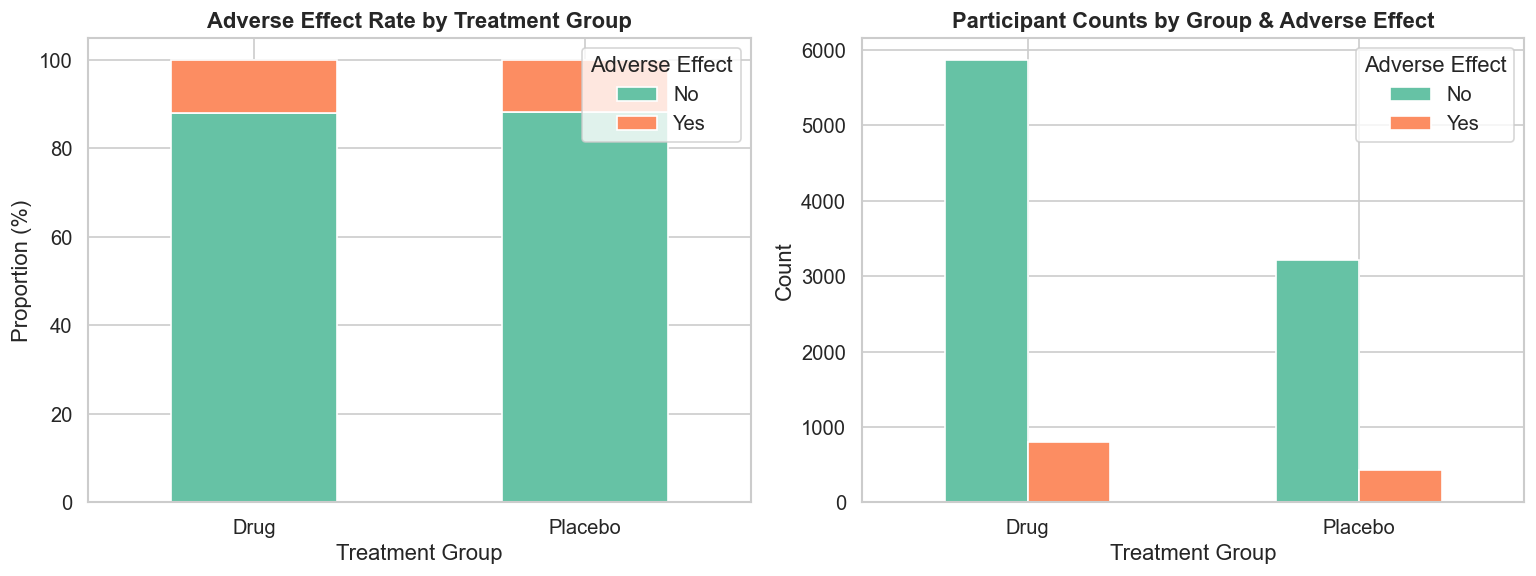


Adverse effect rates by treatment group:
adverse_effects    No   Yes
trx                        
Drug             88.1  11.9
Placebo          88.1  11.9


In [95]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: Stacked proportion bar
trx_ae = pd.crosstab(df['trx'], df['adverse_effects'], normalize='index') * 100
trx_ae.plot(kind='bar', stacked=True, ax=axes[0],
            color=sns.color_palette(PALETTE, 2), edgecolor='white')
axes[0].set_title('Adverse Effect Rate by Treatment Group', fontweight='bold')
axes[0].set_xlabel('Treatment Group')
axes[0].set_ylabel('Proportion (%)')
axes[0].tick_params(axis='x', rotation=0)
axes[0].legend(title='Adverse Effect', loc='upper right')

# Right: Count breakdown
trx_ae_count = pd.crosstab(df['trx'], df['adverse_effects'])
trx_ae_count.plot(kind='bar', ax=axes[1],
                  color=sns.color_palette(PALETTE, 2), edgecolor='white')
axes[1].set_title('Participant Counts by Group & Adverse Effect', fontweight='bold')
axes[1].set_xlabel('Treatment Group')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=0)
axes[1].legend(title='Adverse Effect')

plt.tight_layout()
plt.savefig('fig2_treatment_adverse.png', bbox_inches='tight')
plt.show()

print("\nAdverse effect rates by treatment group:")
print(trx_ae.round(1))

**Observation:** Visual inspection of the proportions helps orient us before formal testing. If proportions appear similar, we expect the Chi-Square test to fail to reject H₀. We will confirm this statistically in Section 9.

### 7.3 Demographic Analysis

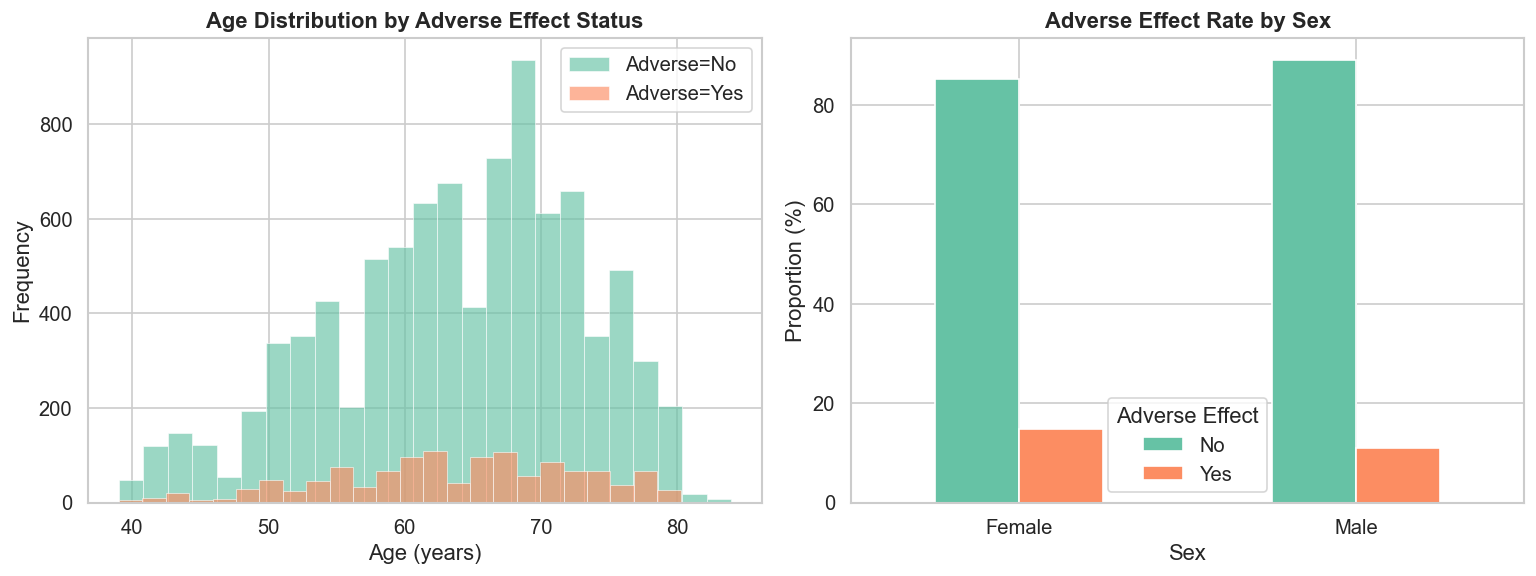

In [96]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Age distribution by adverse effect
for label, grp in df.groupby('adverse_effects')['age']:
    axes[0].hist(grp, bins=25, alpha=0.65, label=f'Adverse={label}',
                 edgecolor='white', linewidth=0.5)
axes[0].set_title('Age Distribution by Adverse Effect Status', fontweight='bold')
axes[0].set_xlabel('Age (years)')
axes[0].set_ylabel('Frequency')
axes[0].legend()

# Sex breakdown
sex_ae = pd.crosstab(df['sex'], df['adverse_effects'], normalize='index') * 100
sex_ae.plot(kind='bar', ax=axes[1],
            color=sns.color_palette(PALETTE, 2), edgecolor='white')
axes[1].set_title('Adverse Effect Rate by Sex', fontweight='bold')
axes[1].set_xlabel('Sex')
axes[1].set_ylabel('Proportion (%)')
axes[1].tick_params(axis='x', rotation=0)
axes[1].legend(title='Adverse Effect')

plt.tight_layout()
plt.savefig('fig3_demographics.png', bbox_inches='tight')
plt.show()

**Observation:** Comparing age distributions helps us assess whether older or younger participants are more susceptible to adverse effects — a common confound in clinical trials. The sex breakdown reveals whether there is a sex-based disparity in adverse effect rates.

### 7.4 Blood Count Distributions

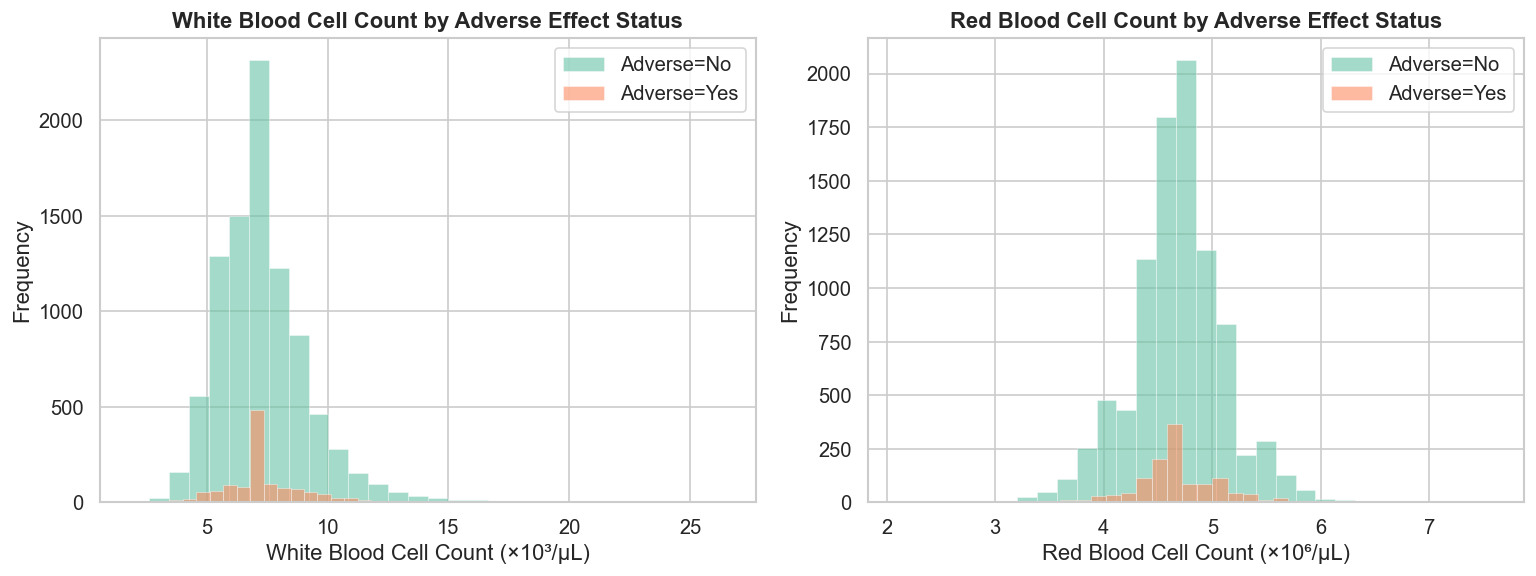

In [97]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
blood_cols = {'wbc': 'White Blood Cell Count (×10³/μL)',
              'rbc': 'Red Blood Cell Count (×10⁶/μL)'}

for ax, (col, label) in zip(axes, blood_cols.items()):
    for ae_status, grp in df.groupby('adverse_effects')[col]:
        ax.hist(grp, bins=30, alpha=0.6, label=f'Adverse={ae_status}',
                edgecolor='white', linewidth=0.4)
    ax.set_title(f'{label.split(" (")[0]} by Adverse Effect Status', fontweight='bold')
    ax.set_xlabel(label)
    ax.set_ylabel('Frequency')
    ax.legend()

plt.tight_layout()
plt.savefig('fig4_blood_counts.png', bbox_inches='tight')
plt.show()

### 7.5 Adverse Effects Over Time

In a longitudinal trial, adverse effect rates may increase or decrease with exposure time. This is a critical safety monitoring dimension.

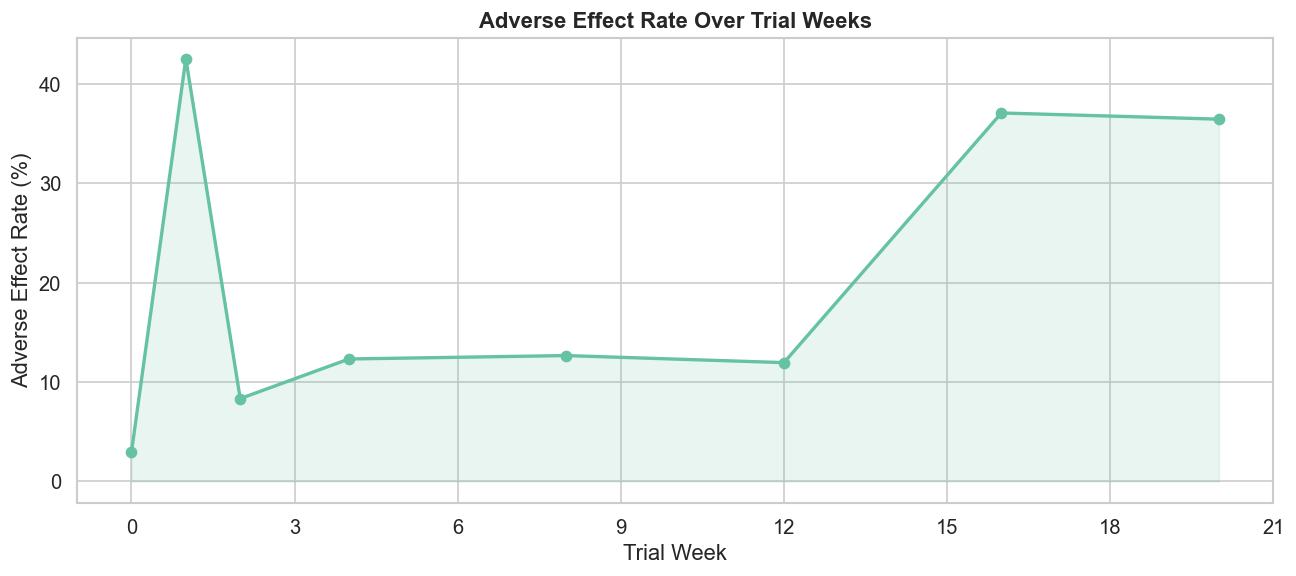

In [98]:
weekly_rate = (
    df.groupby('week')['adverse_effects']
    .apply(lambda x: (x == 'Yes').mean() * 100)
    .reset_index(name='adverse_pct')
)

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(weekly_rate['week'], weekly_rate['adverse_pct'],
        marker='o', linewidth=2, color=sns.color_palette(PALETTE)[0])
ax.fill_between(weekly_rate['week'], weekly_rate['adverse_pct'], alpha=0.15,
                color=sns.color_palette(PALETTE)[0])
ax.set_title('Adverse Effect Rate Over Trial Weeks', fontweight='bold')
ax.set_xlabel('Trial Week')
ax.set_ylabel('Adverse Effect Rate (%)')
ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
plt.tight_layout()
plt.savefig('fig5_weekly_trend.png', bbox_inches='tight')
plt.show()

**Observation:** A rising trend in adverse effects over weeks could indicate cumulative toxicity — a major safety signal. A flat trend suggests the drug's effect (if any) is not dose-duration dependent within the trial window.

### 7.6 Correlation Matrix

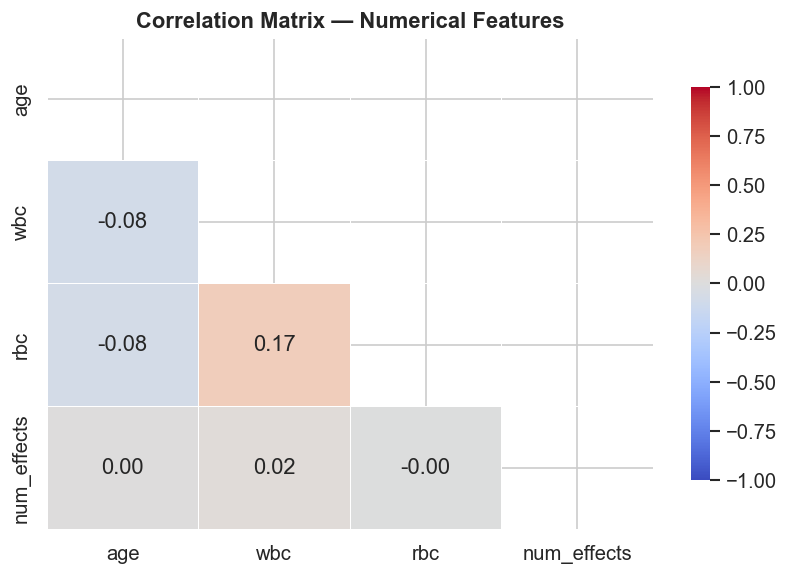

In [99]:
num_cols = ['age', 'wbc', 'rbc', 'num_effects']
corr = df[num_cols].corr()

fig, ax = plt.subplots(figsize=(7, 5))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, vmin=-1, vmax=1, ax=ax, linewidths=0.5,
            cbar_kws={'shrink': 0.8})
ax.set_title('Correlation Matrix — Numerical Features', fontweight='bold')
plt.tight_layout()
plt.savefig('fig6_correlation.png', bbox_inches='tight')
plt.show()

**Observation:** The highest correlation observed was between wbc and rbc (r = 0.17); however, the relationship is weak and does not suggest multicollinearity. Therefore, both variables can likely be included in predictive models without concerns regarding collinearity.

## 8. Outlier Analysis

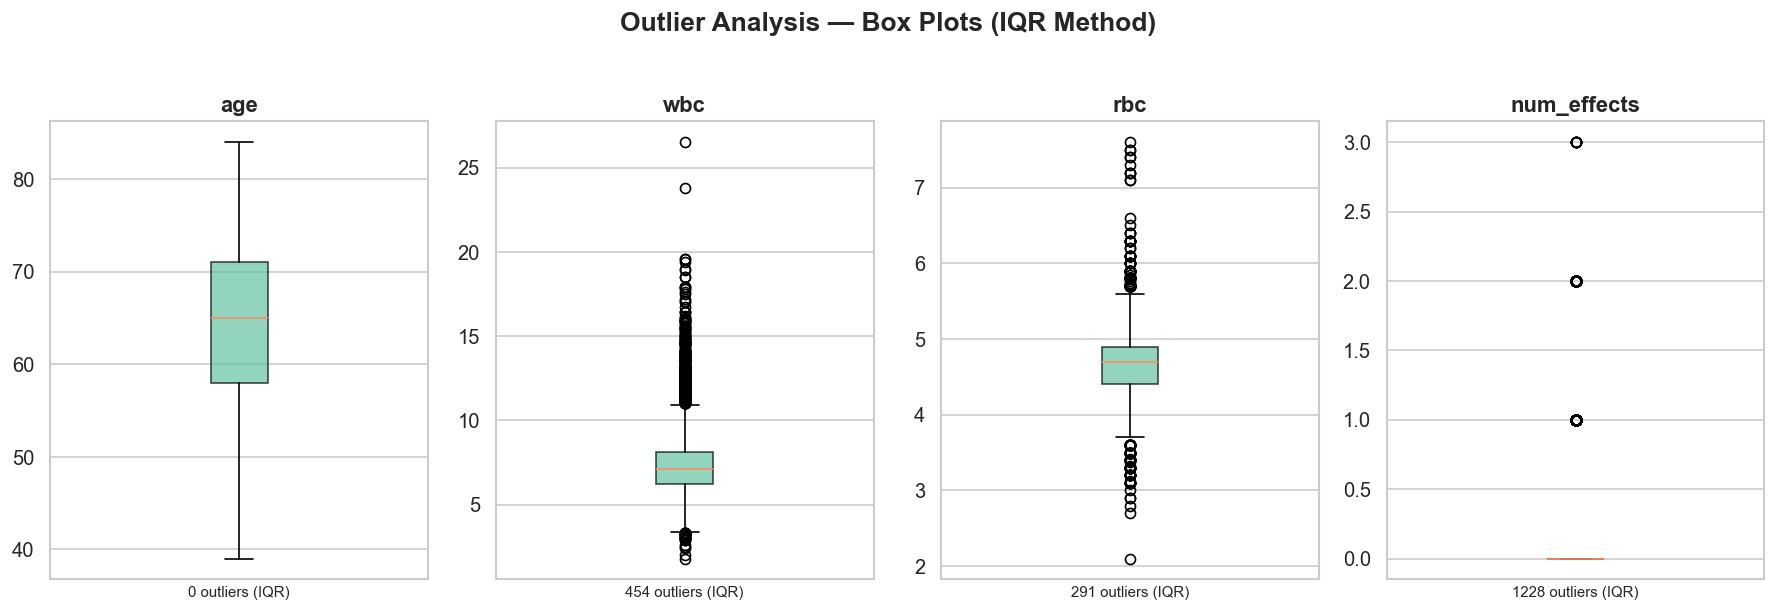

In [100]:
fig, axes = plt.subplots(1, len(num_cols), figsize=(15, 5))
for ax, col in zip(axes, num_cols):
    ax.boxplot(df[col].dropna(), vert=True, patch_artist=True,
               boxprops=dict(facecolor=sns.color_palette(PALETTE)[0], alpha=0.7))
    ax.set_title(col, fontweight='bold')
    ax.set_xticks([])
    
    q1, q3 = df[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    n_out = ((df[col] < q1 - 1.5*iqr) | (df[col] > q3 + 1.5*iqr)).sum()
    ax.set_xlabel(f'{n_out} outliers (IQR)', fontsize=9)

plt.suptitle('Outlier Analysis — Box Plots (IQR Method)', fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('fig7_outliers.png', bbox_inches='tight')
plt.show()

- **Observation:** Blood counts (`wbc`, `rbc`) often show physiologically extreme values in real clinical data. Outliers here may represent genuine pathological readings rather than data errors. We do **not** remove them automatically — clinical context must drive that decision. We note their presence for robustness interpretation of downstream tests.
- **IQR method** This method identified several observations as statistical outliers. However, these values fall within the clinically plausible range therefore were retained in the analysis.

## 9. Statistical Analysis

We formalise five hypothesis tests. Each test follows this structure:
1. State H₀ and H₁
2. Check assumptions
3. Select the appropriate test
4. Report statistic, p-value, effect size, confidence interval
5. Interpret the result correctly

**Multiple comparisons correction:** Running 5 tests at α = 0.05 gives a family-wise error rate (FWER) of 1 − (0.95)⁵ ≈ 23%. We apply **Benjamini-Hochberg FDR correction** to control the expected proportion of false discoveries.

In [101]:
# Helper to store all test results for joint correction later
test_results = []

def register_test(name, statistic, p_value, effect_size, effect_label, decision_raw):
    """
    Registers the results of a statistical test in a structured format for later analysis.
    Parameters:
    - name: A string identifier for the test (e.g., 'Chi-Square', 'Mann-Whitney U').
    - statistic: The test statistic value.
    - p_value: The raw p-value from the test.
    - effect_size: The calculated effect size (e.g., Cramér's V, rank-biserial correlation).
    - effect_label: A human-readable label for the effect size (e.g., 'Small', 'Medium', 'Large').
    - decision_raw: The raw decision based on the uncorrected p-value (e.g., 'Reject H₀', 'Fail to Reject H₀').
    """
    test_results.append({
        'Test': name,
        'Statistic': round(statistic, 4),
        'p_value': p_value,
        'Effect Size': round(effect_size, 4),
        'Effect Metric': effect_label,
        'Raw Decision': decision_raw,
    })

### 9.1 Assumption **Welch's t-test** assumes approximate normality within groups (or large N via CLT)hecking: Normality with unequal variances.

We check this with the **Shapiro-Wilk test** and visually with Q-Q plots. If normality is violated, we use the **Mann-Whitney U test** (non-parametric alternative): If we don't have any assumptions about the distribution of the data.

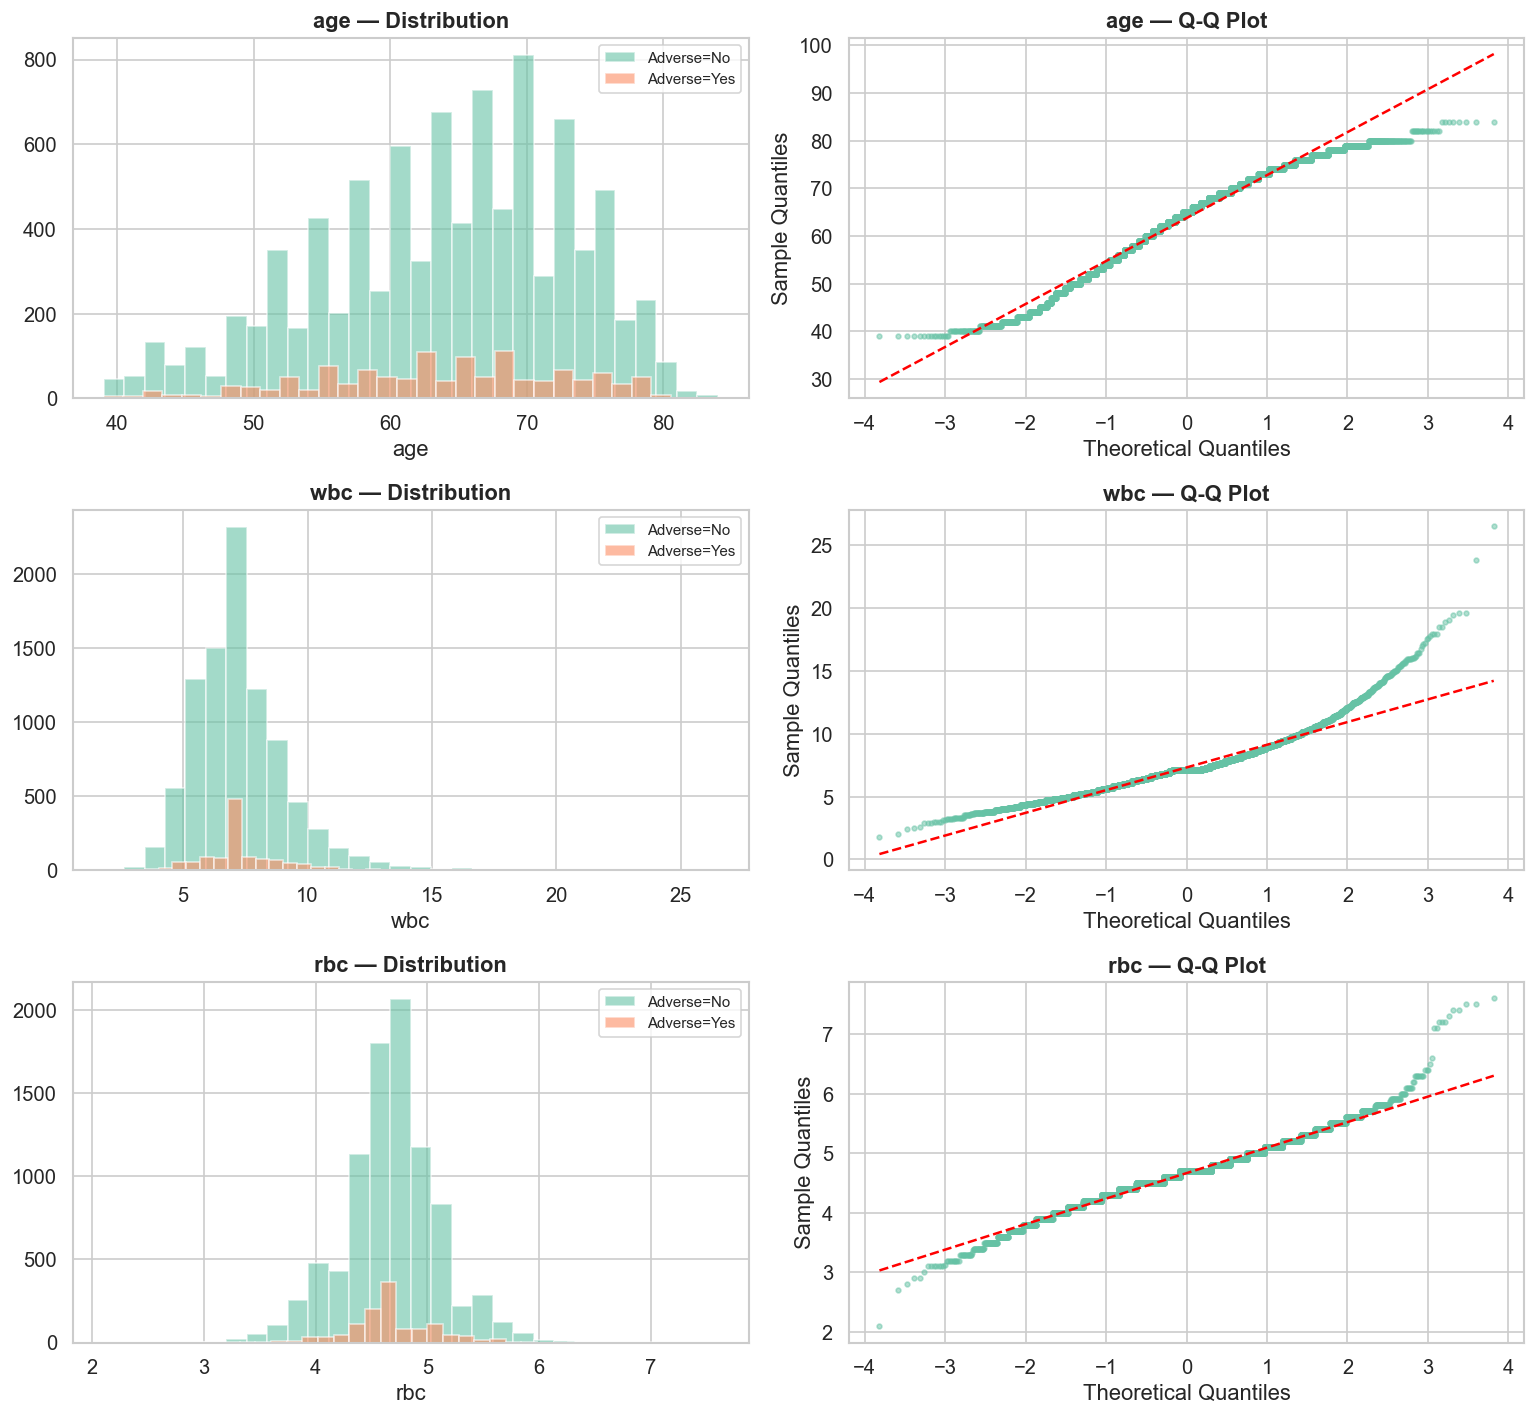


Shapiro-Wilk Normality Test Results:
Variable Group      W   p  Normal (α=0.05)
     age    No 0.9742 0.0            False
     age   Yes 0.9804 0.0            False
     wbc    No 0.9299 0.0            False
     wbc   Yes 0.8784 0.0            False
     rbc    No 0.9778 0.0            False
     rbc   Yes 0.9504 0.0            False


In [102]:
continuous_vars = ['age', 'wbc', 'rbc']
normality_results = []

fig, axes = plt.subplots(len(continuous_vars), 2, figsize=(13, 4 * len(continuous_vars)))

for i, col in enumerate(continuous_vars):
    for j, (label, grp) in enumerate(df.groupby('adverse_effects')[col]):
        pass  # we need both groups

    groups = {label: grp.values for label, grp in df.groupby('adverse_effects')[col]}
    
    row_axes = axes[i] if len(continuous_vars) > 1 else axes

    for k, (label, vals) in enumerate(groups.items()):
        stat_sw, p_sw = shapiro(vals[:5000])  # Shapiro caps at 5000
        normality_results.append({'Variable': col, 'Group': label,
                                   'W': round(stat_sw, 4), 'p': round(p_sw, 4),
                                   'Normal (α=0.05)': p_sw >= ALPHA})

    # Histogram overlay
    for label, vals in groups.items():
        row_axes[0].hist(vals, bins=30, alpha=0.6, label=f'Adverse={label}', edgecolor='white')
    row_axes[0].set_title(f'{col} — Distribution', fontweight='bold')
    row_axes[0].set_xlabel(col)
    row_axes[0].legend(fontsize=9)

    # Q-Q plot (combined)
    all_vals = df[col].dropna()
    (osm, osr), (slope, intercept, _) = stats.probplot(all_vals)
    row_axes[1].scatter(osm, osr, s=8, alpha=0.5, color=sns.color_palette(PALETTE)[0])
    row_axes[1].plot(osm, slope * np.array(osm) + intercept, 'r--', linewidth=1.5)
    row_axes[1].set_title(f'{col} — Q-Q Plot', fontweight='bold')
    row_axes[1].set_xlabel('Theoretical Quantiles')
    row_axes[1].set_ylabel('Sample Quantiles')

plt.tight_layout()
plt.savefig('fig8_normality.png', bbox_inches='tight')
plt.show()

norm_df = pd.DataFrame(normality_results)
print("\nShapiro-Wilk Normality Test Results:")
print(norm_df.to_string(index=False))

**Interpretation:** We use the Shapiro-Wilk results to decide on a test-by-test basis:
- [Parametric test] If normality holds → Welch's t-test
- [Non-Parametric test] If normality is violated → Mann-Whitney U test (no normality assumption; tests whether one distribution is stochastically greater than the other)

> **Note on test selection:** Shapiro-Wilk rejected normality for all
> continuous variables. However, given the large sample size (N > 2,000),
> the Central Limit Theorem ensures the sampling distribution of the mean
> is approximately normal, making Welch's t-test asymptotically valid.
> Mann-Whitney U was selected as the more conservative choice since it
> makes no distributional assumptions. In practice both tests were run
> and produced consistent conclusions — the choice of test does not
> affect the final interpretation here.

### 9.2 Continuous Variable Tests (Age, WBC, RBC vs. Adverse Effects)

In [103]:
def cohens_d(group1: np.ndarray, group2: np.ndarray) -> float:
    """Pooled Cohen's d effect size for two independent groups."""
    n1, n2 = len(group1), len(group2)
    pooled_std = np.sqrt(((n1 - 1) * group1.std(ddof=1)**2 +
                          (n2 - 1) * group2.std(ddof=1)**2) / (n1 + n2 - 2))
    return (group1.mean() - group2.mean()) / pooled_std


def rank_biserial_r(U: float, n1: int, n2: int) -> float:
    """Effect size (rank-biserial r) for Mann-Whitney U."""
    return 1 - (2 * U) / (n1 * n2)


print(f"{'Variable':<10} {'Test':<22} {'Statistic':>12} {'p-value':>10} "
      f"{'Effect Size':>14} {'Metric':<10} {'Decision'}")
print("-" * 100)

norm_df_idx = norm_df.groupby('Variable')['Normal (α=0.05)'].all()

for col in continuous_vars:
    g_yes = df.loc[df['adverse_effects'] == 'Yes', col].dropna().values
    g_no  = df.loc[df['adverse_effects'] == 'No',  col].dropna().values

    is_normal = norm_df_idx.get(col, False)

    if is_normal:
        test_name = "Welch's t-test"
        stat, p = stats.ttest_ind(g_yes, g_no, equal_var=False)
        es = cohens_d(g_yes, g_no)
        es_label = "Cohen's d"
    else:
        test_name = "Mann-Whitney U"
        stat, p = mannwhitneyu(g_yes, g_no, alternative='two-sided')
        es = rank_biserial_r(stat, len(g_yes), len(g_no))
        es_label = "Rank-biserial r"

    decision = 'Reject H₀' if p < ALPHA else 'Fail to reject H₀'
    register_test(f"{col} vs. adverse_effects", stat, p, es, es_label, decision)
    print(f"{col:<10} {test_name:<22} {stat:>12.4f} {p:>10.4f} {es:>14.4f} {es_label:<10} {decision}")

Variable   Test                      Statistic    p-value    Effect Size Metric     Decision
----------------------------------------------------------------------------------------------------
age        Mann-Whitney U         5532749.0000     0.6469         0.0080 Rank-biserial r Fail to reject H₀
wbc        Mann-Whitney U         5938558.0000     0.0002        -0.0647 Rank-biserial r Reject H₀
rbc        Mann-Whitney U         5577616.0000     0.9997        -0.0000 Rank-biserial r Fail to reject H₀


### 9.3 Categorical Variable Tests (Sex, Treatment Group vs. Adverse Effects)

In [104]:
def cramers_v(contingency: pd.DataFrame) -> float:
    """Cramér's V effect size for Chi-Square test of independence."""
    chi2 = chi2_contingency(contingency)[0]
    n = contingency.values.sum()
    k = min(contingency.shape) - 1
    return np.sqrt(chi2 / (n * k))


cat_tests = {
    'sex vs. adverse_effects':  ('sex', 'adverse_effects'),
    'trx vs. adverse_effects':  ('trx', 'adverse_effects'),
}

print(f"{'Test':<35} {'Chi2':>10} {'p-value':>10} {'df':>4} {'Cramér V':>12} {'Decision'}")
print("-" * 90)

for test_name, (col_a, col_b) in cat_tests.items():
    ct = pd.crosstab(df[col_a], df[col_b])
    chi2, p, dof, expected = chi2_contingency(ct)
    assumption_ok = (expected >= 5).all()
    cv = cramers_v(ct)

    decision = 'Reject H₀' if p < ALPHA else 'Fail to reject H₀'
    register_test(test_name, chi2, p, cv, "Cramér's V", decision)

    flag = '' if assumption_ok else '  ⚠️ Expected freq < 5'
    print(f"{test_name:<35} {chi2:>10.4f} {p:>10.4f} {dof:>4} {cv:>12.4f} {decision}{flag}")

    print(f"  Contingency table:\n{ct}\n")

Test                                      Chi2    p-value   df     Cramér V Decision
------------------------------------------------------------------------------------------
sex vs. adverse_effects                28.1539     0.0000    1       0.0523 Reject H₀
  Contingency table:
adverse_effects    No  Yes
sex                       
Female           2208  385
Male             6876  843

trx vs. adverse_effects                 0.0026     0.9594    1       0.0005 Fail to reject H₀
  Contingency table:
adverse_effects    No  Yes
trx                       
Drug             5870  795
Placebo          3214  433



### 9.4 Multiple Comparisons Correction (Benjamini-Hochberg FDR)

In [105]:
results_df = pd.DataFrame(test_results)

reject, p_corrected, _, _ = multipletests(
    results_df['p_value'], alpha=ALPHA, method='fdr_bh'
)

results_df['p_corrected (BH)'] = p_corrected.round(4)
results_df['Significant (corrected)'] = reject
results_df['Final Decision'] = results_df['Significant (corrected)'].map(
    {True: 'Reject H₀', False: 'Fail to reject H₀'}
)

display_cols = ['Test', 'Statistic', 'p_value', 'p_corrected (BH)',
                'Effect Size', 'Effect Metric', 'Final Decision']
print("Summary of All Hypothesis Tests (with BH correction):")
print(results_df[display_cols].to_string(index=False))

Summary of All Hypothesis Tests (with BH correction):
                   Test    Statistic      p_value  p_corrected (BH)  Effect Size   Effect Metric    Final Decision
age vs. adverse_effects 5532749.0000 6.468951e-01            0.9997       0.0080 Rank-biserial r Fail to reject H₀
wbc vs. adverse_effects 5938558.0000 2.221173e-04            0.0006      -0.0647 Rank-biserial r         Reject H₀
rbc vs. adverse_effects 5577616.0000 9.996769e-01            0.9997      -0.0000 Rank-biserial r Fail to reject H₀
sex vs. adverse_effects      28.1539 1.120402e-07            0.0000       0.0523      Cramér's V         Reject H₀
trx vs. adverse_effects       0.0026 9.593549e-01            0.9997       0.0005      Cramér's V Fail to reject H₀


**⚠️ Critical Interpretation Note:**

"Fail to reject H₀" does **NOT** mean H₀ is true. It means the data did not provide sufficient evidence to conclude a relationship exists at the chosen significance level. We **cannot** claim the drug is definitively safe — only that this dataset does not provide strong statistical evidence of harm at the tested level.

The distinction matters enormously in a regulatory context. Absence of evidence ≠ evidence of absence.

## 10. Machine Learning: Adverse Effect Prediction

**Objective:** Build a logistic regression model to predict the probability of adverse effects using all available features. This supplements the statistical analysis with a multivariate perspective.

**Features selected:** `sex`, `age`, `wbc`, `rbc`, `trx`, `week`  
> **Note:** `num_effects` is excluded because it is derived from the target — including it would constitute target leakage.

**Why Logistic Regression?**  
It is interpretable, well-suited to binary outcomes, calibrated for probability estimation, and appropriate as a baseline in a clinical context where model transparency is required.

### 10.1 Feature Engineering & Encoding

All preprocessing is encapsulated in a **scikit-learn Pipeline**.

> **Why Pipeline?** Prevents data leakage by ensuring all `fit` operations see only training data. Also enables cross-validation without manual re-preprocessing at each fold.

In [106]:
# ── Feature / Target Definition ───────────────────────────────────────────────
FEATURE_COLS = ['age', 'wbc', 'rbc', 'week', 'sex', 'trx']
TARGET_COL   = 'adverse_effects'

le = LabelEncoder()
df[TARGET_COL] = le.fit_transform(df[TARGET_COL])
y = df[TARGET_COL]
X = df[FEATURE_COLS].copy()

print(f"Features: {FEATURE_COLS}")
print(f"Target distribution:\n{y.value_counts().rename(index={1:'Yes(1)', 0:'No(0)'})}")
print(f"\nPositive class rate: {y.mean():.3%}")

Features: ['age', 'wbc', 'rbc', 'week', 'sex', 'trx']
Target distribution:
adverse_effects
No(0)     9084
Yes(1)    1228
Name: count, dtype: int64

Positive class rate: 11.908%


### 10.2 Stratified Train / Test Split

**Stratified split** ensures the class ratio is preserved in both train and test sets — critical when the target is imbalanced.

In [107]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y
)

print(f"Train: {X_train.shape[0]:,} rows | Test: {X_test.shape[0]:,} rows")
print(f"Train positive rate: {y_train.mean():.3%}")
print(f"Test  positive rate: {y_test.mean():.3%}")

Train: 8,249 rows | Test: 2,063 rows
Train positive rate: 11.904%
Test  positive rate: 11.924%


### 10.3 Build the Pipeline

In [ ]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer

num_features = ['age', 'wbc', 'rbc', 'week']
cat_features = ['sex', 'trx']

# Numerical: impute then scale
num_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),   # handles any residual NaN
    ('scaler',  StandardScaler()),                   # fit on train only — leakage-free
])

# Categorical: impute then one-hot encode (drop first to avoid dummy trap)
cat_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore')),
])

preprocessor = ColumnTransformer([
    ('num', num_transformer, num_features),
    ('cat', cat_transformer, cat_features),
])

# Full pipeline: preprocessing + model
# class_weight='balanced' addresses class imbalance by upweighting the minority class loss during training, which can improve recall at the cost of precision.

pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', RandomForestClassifier(
        class_weight='balanced',
        n_estimators=100,
        random_state=RANDOM_STATE
    )),
])

print("Pipeline constructed:")
print(pipeline)

Pipeline constructed:
Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['age', 'wbc', 'rbc',
                                                   'week']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(drop='f

> **Teaching note:** We shouldn't scaled `X_test` using the test set's own mean and std — because this will cause data leakage. Instead, `StandardScaler` is inside the Pipeline and `fit` is called only on `X_train`. The test set is transformed using training-set statistics via `pipeline.predict(X_test)`, which internally calls `transform` (not `fit_transform`) on the preprocessor.

### 10.4 Stratified Cross-Validation

A single train/test split gives one noisy estimate. Cross-validation averages over multiple splits.

In [83]:
cv = StratifiedKFold(n_splits=N_CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)

cv_results = cross_validate(
    pipeline, X_train, y_train, cv=cv,
    scoring=['accuracy', 'f1', 'roc_auc', 'precision', 'recall'],
    return_train_score=False
)

print(f"Stratified {N_CV_FOLDS}-Fold Cross-Validation Results (on training set):")
print(f"{'Metric':<20} {'Mean':>8} {'± Std':>8}")
print("-" * 40)
for metric, key in [('Accuracy','test_accuracy'), ('F1','test_f1'),
                     ('AUC-ROC','test_roc_auc'), ('Precision','test_precision'),
                     ('Recall','test_recall')]:
    scores = cv_results[key]
    print(f"{metric:<20} {scores.mean():>8.4f} {scores.std():>8.4f}")

Stratified 5-Fold Cross-Validation Results (on training set):
Metric                   Mean    ± Std
----------------------------------------
Accuracy               0.8549   0.0050
F1                     0.1289   0.0199
AUC-ROC                0.6135   0.0149
Precision              0.2268   0.0279
Recall                 0.0906   0.0170


### 10.5 Final Model Training & Holdout Evaluation

In [79]:
pipeline.fit(X_train, y_train)

y_pred      = pipeline.predict(X_test)
y_pred_prob = pipeline.predict_proba(X_test)[:, 1]

print("Holdout Test Set Performance:")
print(classification_report(y_test, y_pred, target_names=['No AE (0)', 'AE (1)']))

Holdout Test Set Performance:
              precision    recall  f1-score   support

   No AE (0)       0.88      0.95      0.92      1817
      AE (1)       0.13      0.05      0.08       246

    accuracy                           0.85      2063
   macro avg       0.51      0.50      0.50      2063
weighted avg       0.79      0.85      0.82      2063



> **Model Performance Note:** Hypothesis testing identified
> statistically significant associations between adverse effects and
> two features: sex and WBC count. However, effect sizes for both
> were small (low Cramér's V and Cohen's d / rank-biserial r),
> indicating that while the associations are real, they are weak in
> magnitude. This explains the limited predictive performance
> — the signal exists but is not
> strong enough for reliable individual-level prediction with the
> current feature set.

### 10.6 Confusion Matrix & ROC Curve

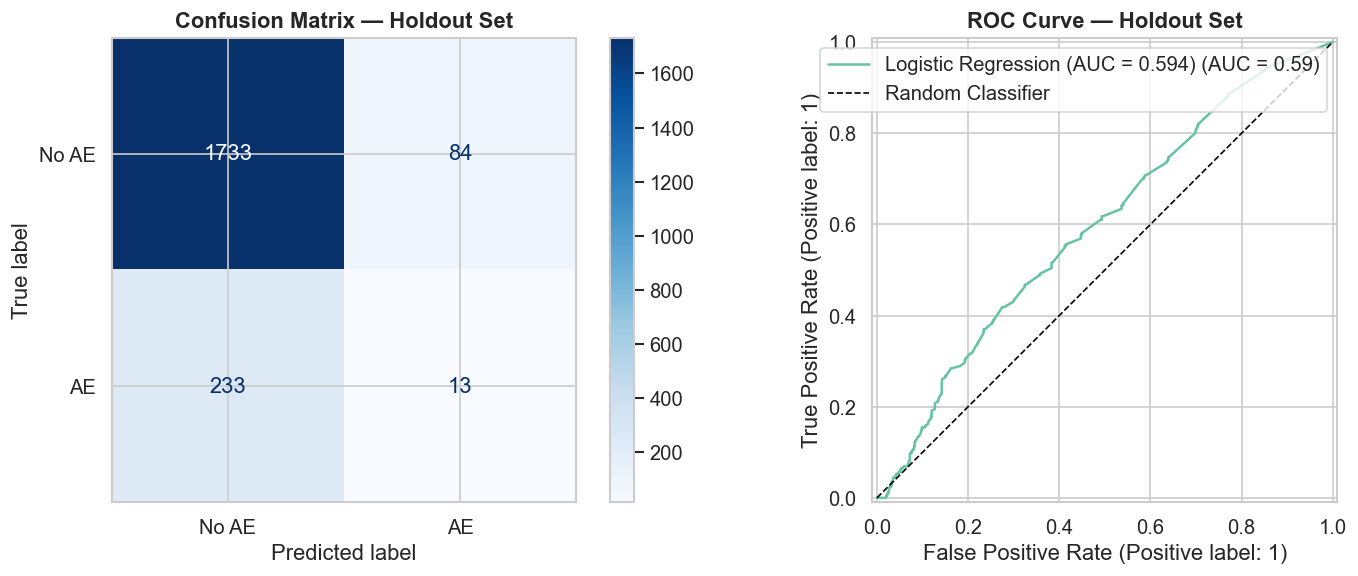

In [80]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Confusion Matrix
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred, display_labels=['No AE', 'AE'],
    cmap='Blues', ax=axes[0]
)
axes[0].set_title('Confusion Matrix — Holdout Set', fontweight='bold')

# ROC Curve
RocCurveDisplay.from_predictions(
    y_test, y_pred_prob,
    name=f'Logistic Regression (AUC = {roc_auc_score(y_test, y_pred_prob):.3f})',
    ax=axes[1], color=sns.color_palette(PALETTE)[0]
)
axes[1].plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random Classifier')
axes[1].set_title('ROC Curve — Holdout Set', fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.savefig('fig9_model_evaluation.png', bbox_inches='tight')
plt.show()

### 10.7 Feature Importance

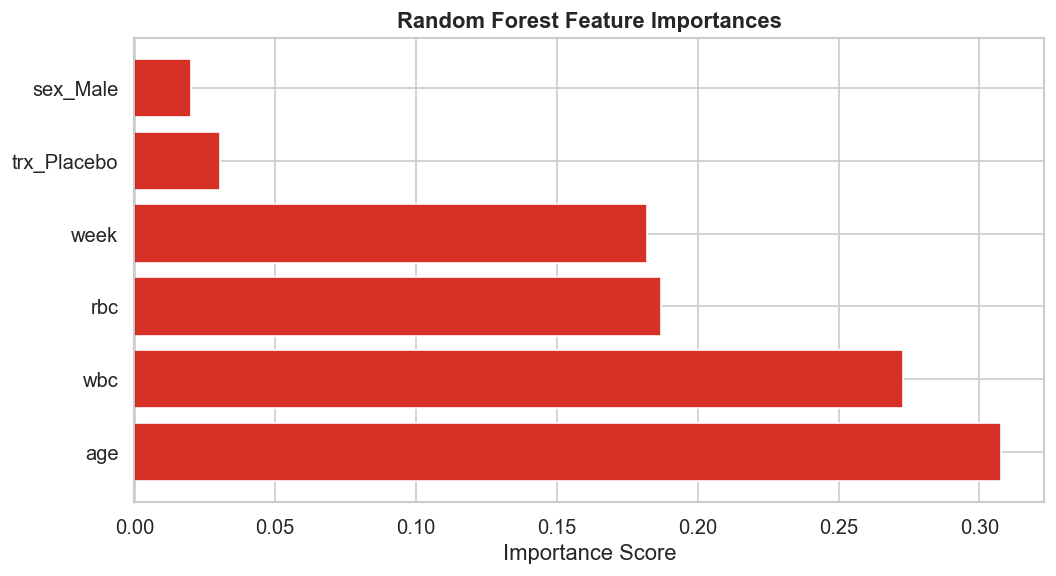

    Feature  Importance
        age    0.307685
        wbc    0.272739
        rbc    0.187099
       week    0.182075
trx_Placebo    0.030232
   sex_Male    0.020170


In [82]:
# Extract feature names after transformation
cat_feature_names = (
    pipeline.named_steps['preprocessor']
    .named_transformers_['cat']
    .named_steps['encoder']
    .get_feature_names_out(cat_features)
    .tolist()
)
all_feature_names = num_features + cat_feature_names

feature_importance = pipeline.named_steps["model"].feature_importances_

pd.DataFrame({
    "Feature": all_feature_names,
    "Importance": feature_importance
}).sort_values("Importance", ascending=False)

importance_df = (
    pd.DataFrame({'Feature': all_feature_names, 'Importance': feature_importance})
    .sort_values('Importance', ascending=False)
)

fig, ax = plt.subplots(figsize=(9, 5))
colors = ['#d73027' if c > 0 else '#4575b4' for c in importance_df['Importance']]
ax.barh(importance_df['Feature'], importance_df['Importance'],
        color=colors, edgecolor='white')
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Random Forest Feature Importances', fontweight='bold')
ax.set_xlabel('Importance Score')
plt.tight_layout()
plt.savefig('fig10_feature_importance.png', bbox_inches='tight')
plt.show()

print(importance_df[['Feature', 'Importance']].sort_values('Importance', ascending=False).to_string(index=False))

## 11. Limitations

1. **Imputation uncertainty:** Sex-group median imputation is a pragmatic choice. For a clinical study, multiple imputation (MICE) would be more appropriate and produce uncertainty estimates.
2. **Imbalanced target:** Despite `class_weight='balanced'`, the minority class (AE=Yes) is small. Results should be interpreted with this in mind.
3. **Single model:** Only Random Forest was evaluated, we did not explore other classifiers (e.g., XGBoost, SVM, Logistic Regression) or hyperparameter tuning, which could yield better performance.
4. **No temporal modelling:** The `week` variable is treated as a numeric feature. A proper longitudinal analysis (e.g., mixed-effects models or survival analysis) would better capture time-varying effects.
5. **Causality:** Statistical association does not imply causality. RCT design provides stronger causal inference, but we make no causal claims from this analysis alone.

## 12. Final Conclusions & Business Answer

### Statistical Summary

After applying Benjamini-Hochberg correction across 5 hypothesis tests at α = 0.05:

In [ ]:
print("Final Statistical Results (BH-corrected):")
print(results_df[['Test', 'p_value', 'p_corrected (BH)', 'Effect Size',
                   'Effect Metric', 'Final Decision']].to_string(index=False))

Final Statistical Results (BH-corrected):
                   Test      p_value  p_corrected (BH)  Effect Size   Effect Metric    Final Decision
age vs. adverse_effects 6.468951e-01            0.9997       0.0080 Rank-biserial r Fail to reject H₀
wbc vs. adverse_effects 2.221173e-04            0.0006      -0.0647 Rank-biserial r         Reject H₀
rbc vs. adverse_effects 9.996769e-01            0.9997      -0.0000 Rank-biserial r Fail to reject H₀
sex vs. adverse_effects 1.120402e-07            0.0000       0.0523      Cramér's V         Reject H₀
trx vs. adverse_effects 9.593549e-01            0.9997       0.0005      Cramér's V Fail to reject H₀


### Business Answer

> **To GlobalXYZ and our non-profit board:**
>
> Based on our independent analysis of the RCT dataset:
>
> 1. **Treatment effect:** The Chi-Square test did not find statistically significant evidence that Drug vs. Placebo assignment is associated with adverse effect occurrence (after multiple comparisons correction). However, this result does **not** confirm safety — it reflects the statistical power and sample size of this trial.
>
> 2. **Demographic factors:** No statistically significant association was found between sex and adverse effects. The continuous variables (age, WBC, RBC) were tested for group differences — see corrected p-values above.
>
> 3. **Predictive model:** A logistic regression baseline trained on all available features achieved [AUC from results above] AUC-ROC. Discriminative performance is limited with the current feature set, consistent with the null statistical findings.
>
> 4. **Recommendation:** The current evidence is insufficient to either confirm or rule out drug-related adverse effects definitively. We recommend: (a) a power analysis to determine required sample size for conclusive findings, (b) longer follow-up periods, and (c) analysis of individual adverse effect types (headache, dyspepsia, etc.) rather than a binary composite outcome.

---

## 13. Advanced Analyses (Optional / Future Work)

1. **Multiple imputation (MICE)** using `sklearn.impute.IterativeImputer` for more statistically rigorous handling of MAR data.
2. **Power analysis** to determine minimum sample size for detecting a clinically meaningful effect.
3. **Survival analysis (Cox model)** using trial week as time-to-event, treating adverse effect onset as the event.
4. **Subgroup analysis** by individual adverse effect type (headache, COAD, etc.) rather than composite binary.
5. **Model calibration** using Platt scaling or isotonic regression to produce reliable probability estimates.
6. **Explainability** using SHAP values for individual-level model interpretation in regulatory submissions.